# Week 4 — 데이터 진단 (Data Analysis)

## 목표
수집한 PDF 데이터의 구조적 특성과 노이즈를 파악해서, 4주차 chunking 비교 실험의 근거를 만든다.

## 분석 항목
1. 문서별 기본 정보 (페이지 수, 파일 크기, 언어)
2. 구조적 특성 (표/이미지/헤더/footnote 유무)
3. 노이즈 패턴 (페이지번호, 머리말/꼬리말, 반복 텍스트)
4. 문서 길이 분포 (tiktoken 기준 토큰 수)
5. 한국어 vs 영어 문서 비교

---
## 1. 경로 / 설정

In [1]:
from pathlib import Path
import json

PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

# manifest 로드
manifest_path = DATA_RAW / "metadata" / "manifest.json"
if manifest_path.exists():
    with open(manifest_path, encoding="utf-8") as f:
        manifest = json.load(f)
    meta_lookup = {m["filename"]: m for m in manifest if m.get("downloaded")}
else:
    meta_lookup = {}

pdf_paths = sorted((DATA_RAW / "pdf").rglob("*.pdf"))
print(f"분석 대상 PDF: {len(pdf_paths)}개")
for p in pdf_paths:
    print(f"  {p.parent.name}/{p.name}")

분석 대상 PDF: 10개
  esmo/esmo_breast_cancer_patient_guide_korean.pdf
  kbcs/kbcs_korean_breast_cancer_guideline_2023.pdf
  ncc/ncc_breast_cancer_hormone_therapy.pdf
  ncc/ncc_breast_cancer_prevention_guide.pdf
  ncc/ncc_breast_cancer_screening_guideline_2015.pdf
  nccn/nccn_breast_cancer_screening_diagnosis_patient.pdf
  nccn/nccn_dcis_patient.pdf
  nccn/nccn_inflammatory_breast_cancer_patient.pdf
  nccn/nccn_invasive_breast_cancer_patient.pdf
  nccn/nccn_metastatic_breast_cancer_patient.pdf


---
## 2. 문서별 기본 정보 수집

PyMuPDF로 페이지 수, 파일 크기, 표/이미지 개수를 한 번에 추출한다.

In [2]:
import fitz  # PyMuPDF
import pandas as pd


def inspect_pdf(pdf_path: Path) -> dict:
    """PDF 1개의 구조적 정보 추출."""
    doc = fitz.open(str(pdf_path))

    total_pages = len(doc)
    total_chars = 0
    total_images = 0
    total_tables = 0
    pages_with_text = 0

    for page in doc:
        text = page.get_text()
        if text.strip():
            pages_with_text += 1
        total_chars += len(text)
        total_images += len(page.get_images())
        # PyMuPDF의 find_tables는 1.23+ 버전 필요
        try:
            tables = page.find_tables()
            total_tables += len(tables.tables) if hasattr(tables, "tables") else 0
        except Exception:
            pass

    doc.close()

    extra = meta_lookup.get(pdf_path.name, {})
    return {
        "filename": pdf_path.name,
        "org": extra.get("org", pdf_path.parent.name),
        "language": extra.get("language", "?"),
        "doc_type": extra.get("doc_type", "?"),
        "file_size_mb": round(pdf_path.stat().st_size / 1024 / 1024, 2),
        "pages": total_pages,
        "pages_with_text": pages_with_text,
        "total_chars": total_chars,
        "avg_chars_per_page": round(total_chars / max(total_pages, 1)),
        "images": total_images,
        "tables": total_tables,
    }


rows = []
for p in pdf_paths:
    try:
        rows.append(inspect_pdf(p))
        print(f"  OK   {p.name}")
    except Exception as e:
        print(f"  FAIL {p.name}: {e}")

df_basic = pd.DataFrame(rows)
df_basic

Consider using the pymupdf_layout package for a greatly improved page layout analysis.
  OK   esmo_breast_cancer_patient_guide_korean.pdf
  OK   kbcs_korean_breast_cancer_guideline_2023.pdf
  OK   ncc_breast_cancer_hormone_therapy.pdf
  OK   ncc_breast_cancer_prevention_guide.pdf
  OK   ncc_breast_cancer_screening_guideline_2015.pdf
  OK   nccn_breast_cancer_screening_diagnosis_patient.pdf
  OK   nccn_dcis_patient.pdf
  OK   nccn_inflammatory_breast_cancer_patient.pdf
  OK   nccn_invasive_breast_cancer_patient.pdf
  OK   nccn_metastatic_breast_cancer_patient.pdf


,filename,org,language,doc_type,file_size_mb,pages,pages_with_text,total_chars,avg_chars_per_page,images,tables
0,esmo_breast_cancer_patient_guide_korean.pdf,ESMO,ko,patient_guideline,2.51,70,70,75218,1075,43,26
1,kbcs_korean_breast_cancer_guideline_2023.pdf,대한유방암학회,ko,clinical_guideline,2.45,270,258,475413,1761,13,76
2,ncc_breast_cancer_hormone_therapy.pdf,국립암센터,ko,patient_guide,0.22,2,2,1656,828,13,1
3,ncc_breast_cancer_prevention_guide.pdf,국립암센터,ko,patient_guide,4.88,10,9,9818,982,26,7
4,ncc_breast_cancer_screening_guideline_2015.pdf,국립암센터,ko,screening_guideline,1.63,114,112,124808,1095,25,61
5,nccn_breast_cancer_screening_diagnosis_patient...,NCCN,en,patient_guideline,2.94,52,52,81928,1576,21,0
6,nccn_dcis_patient.pdf,NCCN,en,patient_guideline,2.07,52,52,75588,1454,23,2
7,nccn_inflammatory_breast_cancer_patient.pdf,NCCN,en,patient_guideline,2.23,74,74,123195,1665,34,5
8,nccn_invasive_breast_cancer_patient.pdf,NCCN,en,patient_guideline,3.03,86,86,138449,1610,42,5
9,nccn_metastatic_breast_cancer_patient.pdf,NCCN,en,patient_guideline,2.69,66,66,114147,1730,25,5


### 한국어 vs 영어 문서 요약

In [3]:
summary_by_lang = (
    df_basic.groupby("language")
    .agg(
        문서수=("filename", "count"),
        총페이지=("pages", "sum"),
        평균페이지=("pages", "mean"),
        평균이미지수=("images", "mean"),
        평균표수=("tables", "mean"),
    )
    .round(1)
)
summary_by_lang

,문서수,총페이지,평균페이지,평균이미지수,평균표수
language,,,,,
en,5,330,66.0,29.0,3.4
ko,5,466,93.2,24.0,34.2


---
## 3. 페이지별 텍스트 추출 → 노이즈 패턴 진단

각 페이지에서 자주 반복되는 짧은 텍스트(머리말/꼬리말/페이지번호 등)를 자동으로 식별한다.

In [4]:
import re
from collections import Counter


def extract_repeated_lines(pdf_path: Path, top_n: int = 10, min_pages: int = 3) -> list:
    """여러 페이지에 반복되는 짧은 줄을 찾는다 (머리말/꼬리말 후보)."""
    doc = fitz.open(str(pdf_path))
    line_counter = Counter()

    for page in doc:
        text = page.get_text()
        lines = [l.strip() for l in text.split("\n") if l.strip()]
        # 너무 긴 줄은 본문일 가능성 → 제외 (50자 이하만)
        short_lines = set(l for l in lines if 1 <= len(l) <= 50)
        for l in short_lines:
            line_counter[l] += 1

    doc.close()
    # min_pages 이상 등장한 줄만
    repeated = [
        (text, cnt)
        for text, cnt in line_counter.most_common(top_n * 3)
        if cnt >= min_pages
    ]
    return repeated[:top_n]


# 샘플 1개 PDF로 확인
sample = pdf_paths[0]
print(f"--- {sample.name} 반복 줄 top 10 ---")
for text, cnt in extract_repeated_lines(sample):
    print(f"  [{cnt}회] {text!r}")

--- esmo_breast_cancer_patient_guide_korean.pdf 반복 줄 top 10 ---
  [35회] '유방암'
  [35회] '환자를 위한 ESMO 안내서'
  [18회] '발생할 수 있는 부작용'
  [18회] '•\t 메스꺼움'
  [18회] '부작용 관리 방법'
  [15회] '•'
  [15회] '•\t 구토'
  [15회] '•\t 설사'
  [15회] '•\t 신경성 식욕 부진증'
  [14회] '있습니다.'


### 페이지 번호 패턴 자동 감지

In [5]:
PAGE_NUM_PATTERNS = [
    re.compile(r"^\d{1,4}$"),  # 그냥 숫자만
    re.compile(r"^- ?\d{1,4} ?-$"),  # -12-
    re.compile(r"^Page \d+", re.IGNORECASE),  # Page 12
    re.compile(r"^\d+\s*/\s*\d+$"),  # 12 / 24
]


def detect_noise_patterns(pdf_path: Path) -> dict:
    """PDF에서 발견된 노이즈 패턴 카운트."""
    doc = fitz.open(str(pdf_path))
    page_num_hits = 0
    repeated_short = 0
    line_counter = Counter()

    for page in doc:
        text = page.get_text()
        lines = [l.strip() for l in text.split("\n") if l.strip()]
        for l in lines:
            if any(p.match(l) for p in PAGE_NUM_PATTERNS):
                page_num_hits += 1
            if 1 <= len(l) <= 50:
                line_counter[l] += 1

    doc.close()
    repeated_short = sum(1 for cnt in line_counter.values() if cnt >= 3)
    return {
        "page_number_hits": page_num_hits,
        "repeated_short_lines": repeated_short,
    }


noise_rows = []
for p in pdf_paths:
    try:
        d = detect_noise_patterns(p)
        d["filename"] = p.name
        noise_rows.append(d)
    except Exception as e:
        print(f"FAIL {p.name}: {e}")

df_noise = pd.DataFrame(noise_rows)[
    ["filename", "page_number_hits", "repeated_short_lines"]
]
df_basic_with_noise = df_basic.merge(df_noise, on="filename", how="left")
df_basic_with_noise

,filename,org,language,doc_type,file_size_mb,pages,pages_with_text,total_chars,avg_chars_per_page,images,tables,page_number_hits,repeated_short_lines
0,esmo_breast_cancer_patient_guide_korean.pdf,ESMO,ko,patient_guideline,2.51,70,70,75218,1075,43,26,88,147
1,kbcs_korean_breast_cancer_guideline_2023.pdf,대한유방암학회,ko,clinical_guideline,2.45,270,258,475413,1761,13,76,306,242
2,ncc_breast_cancer_hormone_therapy.pdf,국립암센터,ko,patient_guide,0.22,2,2,1656,828,13,1,0,0
3,ncc_breast_cancer_prevention_guide.pdf,국립암센터,ko,patient_guide,4.88,10,9,9818,982,26,7,22,4
4,ncc_breast_cancer_screening_guideline_2015.pdf,국립암센터,ko,screening_guideline,1.63,114,112,124808,1095,25,61,827,343
5,nccn_breast_cancer_screening_diagnosis_patient...,NCCN,en,patient_guideline,2.94,52,52,81928,1576,21,0,84,33
6,nccn_dcis_patient.pdf,NCCN,en,patient_guideline,2.07,52,52,75588,1454,23,2,72,29
7,nccn_inflammatory_breast_cancer_patient.pdf,NCCN,en,patient_guideline,2.23,74,74,123195,1665,34,5,98,41
8,nccn_invasive_breast_cancer_patient.pdf,NCCN,en,patient_guideline,3.03,86,86,138449,1610,42,5,112,46
9,nccn_metastatic_breast_cancer_patient.pdf,NCCN,en,patient_guideline,2.69,66,66,114147,1730,25,5,103,29


In [ ]:
# 827 너무 많아서 오탐인지 확인하는 용도 
from collections import Counter

# 검진권고안에서 '페이지번호로 감지된' 줄이 실제로 뭔지 확인
target = [p for p in pdf_paths if "screening_guideline_2015" in p.name][0]

doc = fitz.open(str(target))
hits = []
for pno, page in enumerate(doc):
    lines = [l.strip() for l in page.get_text().split("\n") if l.strip()]
    for l in lines:
        if any(p.match(l) for p in PAGE_NUM_PATTERNS):
            hits.append((pno, l))
doc.close()

print(f"총 감지: {len(hits)}개\n")

print("--- 감지된 줄 샘플 40개 (페이지, 내용) ---")
for pno, l in hits[:40]:
    print(f"  p.{pno}: {l!r}")

print("\n--- 감지된 '값'별 빈도 top 20 ---")
for val, cnt in Counter(l for _, l in hits).most_common(20):
    print(f"  {cnt}회: {val!r}")

총 감지: 827개

--- 감지된 줄 샘플 40개 (페이지, 내용) ---
  p.4: '1'
  p.4: '1'
  p.5: '2'
  p.6: '3'
  p.6: '2'
  p.7: '4'
  p.7: '3'
  p.8: '5'
  p.9: '6'
  p.9: '88'
  p.10: '7'
  p.10: '4'
  p.11: '8'
  p.12: '9'
  p.12: '5'
  p.13: '10'
  p.14: '11'
  p.14: '9'
  p.14: '6'
  p.14: '7'
  p.14: '6'
  p.14: '7'
  p.14: '7'
  p.14: '7'
  p.14: '5'
  p.14: '4'
  p.15: '12'
  p.16: '13'
  p.17: '14'
  p.18: '15'
  p.19: '16'
  p.20: '17'
  p.20: '6'
  p.21: '18'
  p.22: '19'
  p.23: '20'
  p.24: '21'
  p.25: '22'
  p.26: '23'
  p.27: '24'

--- 감지된 '값'별 빈도 top 20 ---
  19회: '7'
  17회: '6'
  16회: '1'
  16회: '3'
  15회: '4'
  14회: '5'
  14회: '9'
  13회: '2'
  13회: '12'
  12회: '8'
  12회: '10'
  12회: '11'
  12회: '15'
  11회: '13'
  11회: '14'
  11회: '20'
  10회: '25'
  10회: '2013'
  9회: '16'
  9회: '24'


---
## 4. 페이지 단위 텍스트 → 토큰 길이 분포

tiktoken으로 페이지별 토큰 수를 계산한다.  
이 분포가 chunk_size를 정하는 핵심 근거가 된다.

In [6]:
import tiktoken

# tiktoken은 OpenAI tokenizer지만, 일반적인 토큰 길이 추정용으로 표준처럼 쓰임
enc = tiktoken.get_encoding("cl100k_base")


def page_token_lengths(pdf_path: Path) -> list[int]:
    doc = fitz.open(str(pdf_path))
    lens = []
    for page in doc:
        text = page.get_text()
        lens.append(len(enc.encode(text)))
    doc.close()
    return lens


page_token_rows = []
for p in pdf_paths:
    try:
        lens = page_token_lengths(p)
        extra = meta_lookup.get(p.name, {})
        for i, n in enumerate(lens):
            page_token_rows.append(
                {
                    "filename": p.name,
                    "org": extra.get("org", p.parent.name),
                    "language": extra.get("language", "?"),
                    "page": i + 1,
                    "tokens": n,
                }
            )
    except Exception as e:
        print(f"FAIL {p.name}: {e}")

df_tokens = pd.DataFrame(page_token_rows)
print(f"전체 페이지 수: {len(df_tokens)}")
print(df_tokens.groupby("language")["tokens"].describe().round(1))

전체 페이지 수: 796
          count   mean    std  min    25%    50%     75%     max
language                                                        
en        330.0  398.3  209.5  2.0  283.0  437.0   559.8   904.0
ko        466.0  947.5  468.2  0.0  651.0  891.5  1310.8  2002.0


### 시각화 1 — 페이지당 토큰 수 분포 (히스토그램)

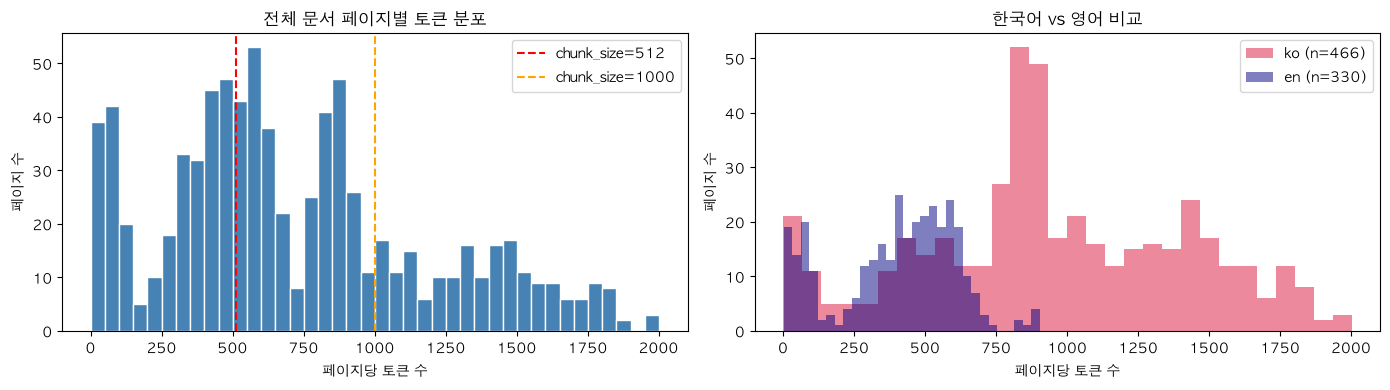

In [7]:
import matplotlib.pyplot as plt
import matplotlib

# 한글 폰트 설정 (Windows / Mac 둘 다 시도)
for font in ["Malgun Gothic", "AppleGothic", "NanumGothic"]:
    if any(font in f.name for f in matplotlib.font_manager.fontManager.ttflist):
        matplotlib.rcParams["font.family"] = font
        break
matplotlib.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# (좌) 전체 분포
axes[0].hist(df_tokens["tokens"], bins=40, color="steelblue", edgecolor="white")
axes[0].axvline(512, color="red", linestyle="--", label="chunk_size=512")
axes[0].axvline(1000, color="orange", linestyle="--", label="chunk_size=1000")
axes[0].set_xlabel("페이지당 토큰 수")
axes[0].set_ylabel("페이지 수")
axes[0].set_title("전체 문서 페이지별 토큰 분포")
axes[0].legend()

# (우) 언어별 비교
for lang, color in [("ko", "crimson"), ("en", "navy")]:
    sub = df_tokens[df_tokens["language"] == lang]["tokens"]
    if len(sub):
        axes[1].hist(
            sub, bins=30, alpha=0.5, label=f"{lang} (n={len(sub)})", color=color
        )
axes[1].set_xlabel("페이지당 토큰 수")
axes[1].set_ylabel("페이지 수")
axes[1].set_title("한국어 vs 영어 비교")
axes[1].legend()

plt.tight_layout()
plt.savefig(
    DATA_PROCESSED / "week4_token_distribution.png", dpi=120, bbox_inches="tight"
)
plt.show()

### 시각화 2 — 문서별 페이지 토큰 박스플롯

/var/folders/nl/dz9l9yk52jdbzpg278r7y5sc0000gn/T/ipykernel_11976/3525505977.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data, tick_labels=labels, vert=False)


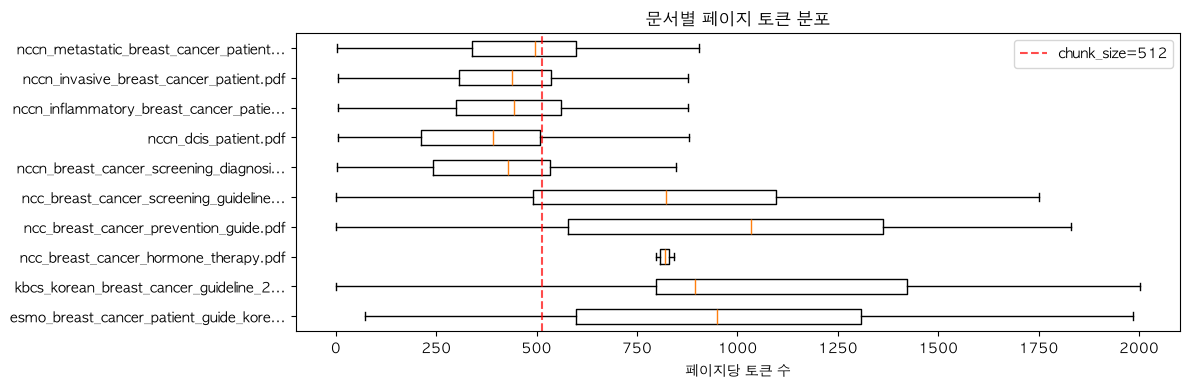

In [8]:
# 파일별 박스플롯 (긴 파일명은 줄임)
fig, ax = plt.subplots(figsize=(12, max(4, len(pdf_paths) * 0.4)))

data = []
labels = []
for fn, sub in df_tokens.groupby("filename"):
    data.append(sub["tokens"].tolist())
    short = fn if len(fn) <= 40 else fn[:37] + "..."
    labels.append(short)

ax.boxplot(data, tick_labels=labels, vert=False)
ax.axvline(512, color="red", linestyle="--", alpha=0.7, label="chunk_size=512")
ax.set_xlabel("페이지당 토큰 수")
ax.set_title("문서별 페이지 토큰 분포")
ax.legend()
plt.tight_layout()
plt.savefig(DATA_PROCESSED / "week4_token_boxplot.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 5. 구조적 특성 진단 (수동 확인용 샘플)

표/이미지가 많은 문서는 자동 카운트만으로는 부족하다. 페이지를 직접 보고 "어떤 구조인지" 확인해야 한다.  
여기서는 각 PDF의 **표/이미지 비율이 높은 페이지**를 추출해 어디를 확인해야 할지 알려준다.

In [9]:
def find_image_heavy_pages(pdf_path: Path, top_n: int = 3) -> list:
    doc = fitz.open(str(pdf_path))
    page_info = []
    for i, page in enumerate(doc):
        img_count = len(page.get_images())
        text_len = len(page.get_text())
        page_info.append((i + 1, img_count, text_len))
    doc.close()
    page_info.sort(key=lambda x: x[1], reverse=True)
    return page_info[:top_n]


print("각 PDF의 이미지가 많은 페이지 top 3:")
for p in pdf_paths:
    heavy = find_image_heavy_pages(p)
    if heavy[0][1] > 0:
        print(f"\n{p.name}")
        for pg, imgs, chars in heavy:
            print(f"  p.{pg}: 이미지 {imgs}개 / 텍스트 {chars}자")

각 PDF의 이미지가 많은 페이지 top 3:

esmo_breast_cancer_patient_guide_korean.pdf
  p.58: 이미지 18개 / 텍스트 1097자
  p.14: 이미지 3개 / 텍스트 999자
  p.9: 이미지 2개 / 텍스트 595자

kbcs_korean_breast_cancer_guideline_2023.pdf
  p.181: 이미지 8개 / 텍스트 189자
  p.1: 이미지 5개 / 텍스트 209자
  p.2: 이미지 0개 / 텍스트 484자

ncc_breast_cancer_hormone_therapy.pdf
  p.1: 이미지 8개 / 텍스트 787자
  p.2: 이미지 5개 / 텍스트 869자

ncc_breast_cancer_prevention_guide.pdf
  p.3: 이미지 7개 / 텍스트 982자
  p.5: 이미지 4개 / 텍스트 527자
  p.6: 이미지 4개 / 텍스트 1346자

ncc_breast_cancer_screening_guideline_2015.pdf
  p.9: 이미지 2개 / 텍스트 112자
  p.25: 이미지 2개 / 텍스트 683자
  p.48: 이미지 2개 / 텍스트 70자

nccn_breast_cancer_screening_diagnosis_patient.pdf
  p.42: 이미지 5개 / 텍스트 1031자
  p.3: 이미지 4개 / 텍스트 1203자
  p.27: 이미지 2개 / 텍스트 2241자

nccn_dcis_patient.pdf
  p.25: 이미지 5개 / 텍스트 1181자
  p.3: 이미지 4개 / 텍스트 1382자
  p.1: 이미지 1개 / 텍스트 330자

nccn_inflammatory_breast_cancer_patient.pdf
  p.44: 이미지 6개 / 텍스트 1820자
  p.57: 이미지 6개 / 텍스트 754자
  p.3: 이미지 4개 / 텍스트 1387자

nccn_invasive_breast_cancer_patient.pdf
